In [2]:
%pip install seaborn

mambajs 0.21.1

Process pip requirements ...

Requirement numpy already satisfied.
Cannot install 'pandas' from PyPI because it is a binary built package that is not compatible with WASM environments. To resolve this issue, you can: 1) Try to install it from emscripten-forge instead: "!mamba install pandas" 2) If that doesn't work, it's probably that the package was not made WASM-compatible on emscripten-forge. You can either request or contribute a new recipe for that package in https://github.com/emscripten-forge/recipes 
Requirement matplotlib already satisfied.


In [3]:
%pip install matplotlib 

mambajs 0.21.1

Process pip requirements ...

Requirement matplotlib already handled by conda/micromamba/mamba.


In [4]:
!mamba install pandas

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 15.471799999952315 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.3    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.2   pyhd8ed1ab_0         conda-forge
- pip            26.1.2   pyh145f28c_0         conda-forge


In [5]:
import seaborn as sns

In [6]:
import matplotlib.pyplot as plt

In [7]:
import pandas as pd

In [8]:

df=pd.read_csv('Superstore_Dataset.csv')
print(df.head())



   Unnamed: 0.1  Unnamed: 0  Row ID        Order ID  Order Date   Ship Date  \
0             0           0       1  CA-2017-152156  2017-08-11  2017-11-11   
1             1           1       2  CA-2017-152156  2017-08-11  2017-11-11   
2             2           2       3  CA-2017-138688  2017-12-06         NaN   
3             3           3       4  US-2016-108966  2016-11-10         NaN   
4             4           4       5  US-2016-108966  2016-11-10         NaN   

        Ship Mode Customer ID    Customer Name    Segment  ... Postal Code  \
0    Second Class    CG-12520      Claire Gute   Consumer  ...     42420.0   
1    Second Class    CG-12520      Claire Gute   Consumer  ...     42420.0   
2    Second Class    DV-13045  Darrin Van Huff  Corporate  ...     90036.0   
3  Standard Class    SO-20335   Sean O'Donnell   Consumer  ...     33311.0   
4  Standard Class    SO-20335   Sean O'Donnell   Consumer  ...     33311.0   

  Region       Product ID         Category Sub-Category 

In [9]:
#Finding missing values
df.isnull().sum()

Unnamed: 0.1        0
Unnamed: 0          0
Row ID              0
Order ID            0
Order Date       5841
Ship Date        5985
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Year             5841
Month            5841
Month_Number     5841
dtype: int64

In [10]:
#Filling missing values
df['Postal Code']=df['Postal Code'].fillna("Unknown")

In [11]:

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True,errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True,errors='coerce')
df['Year']=df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month_name()
df['Month_Number']=df['Order Date'].dt.month
df.to_csv('Superstore_Dataset.csv')


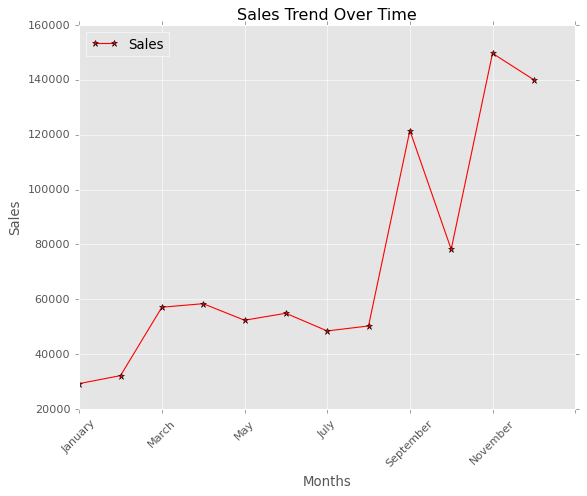

In [37]:
# Sales Trend Over Time
plt.style.use('ggplot')
pivot=df.pivot_table(
    values='Sales',
    index=['Month_Number','Month'],
    aggfunc='sum'
).sort_index()

#Display only month names remove Month_Number index
pivot.index=pivot.index.get_level_values('Month')

ax=pivot.plot(kind='line',color='red',marker='*')
ax.set_title('Sales Trend Over Time')
ax.set_xlabel('Months')
ax.set_ylabel('Sales')
plt.xticks(rotation=45)
plt.savefig('Chart1_Monthly_Sales',  dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

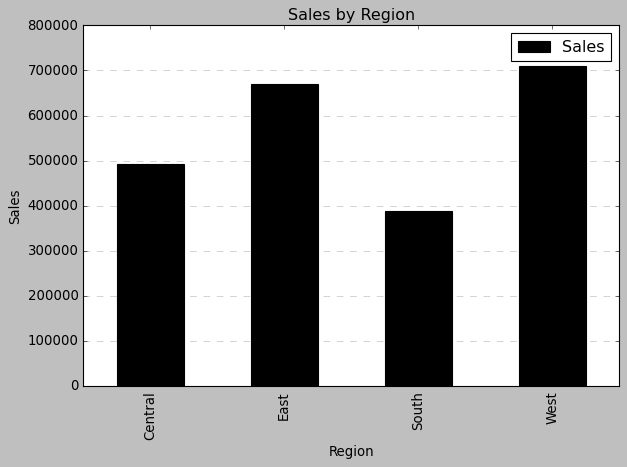

In [40]:
# Sales by Region

pivot=df.pivot_table(
    values='Sales',
    index='Region',
    aggfunc='sum'
)

ax=pivot.plot(kind='bar',color='black')
ax.set_title('Sales by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Sales')
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.savefig('Chart2_Sales_by_Region',  dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


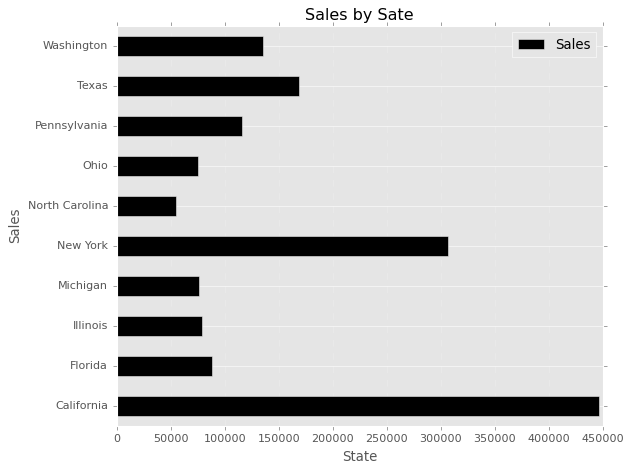

In [33]:

# Sales by State

topstates=df['State'].value_counts().head(10).index
topdf=df[df['State'].isin(topstates)]
pivot=topdf.pivot_table(
    values='Sales',
    index='State',
    aggfunc='sum'
)

ax=pivot.plot(kind='barh',color='black')
ax.set_title('Sales by State')
ax.set_xlabel('State')
ax.set_ylabel('Sales')
ax.grid(axis='x',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.savefig('Chart3_Sales_by_State',  dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


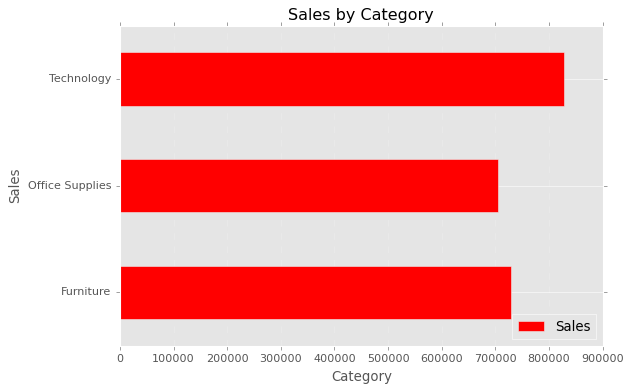

In [32]:
#Sales by category
pivot=df.pivot_table(
    values='Sales',
    index='Category',
    aggfunc='sum'
)
plt.style.use('ggplot')
ax=pivot.plot(kind='barh',color='red',figsize=(8,5))
ax.set_title('Sales by Category')
ax.set_xlabel('Category')
ax.set_ylabel('Sales')
ax.grid(axis='x',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.savefig('Chart4_Sales_by_Category',  dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

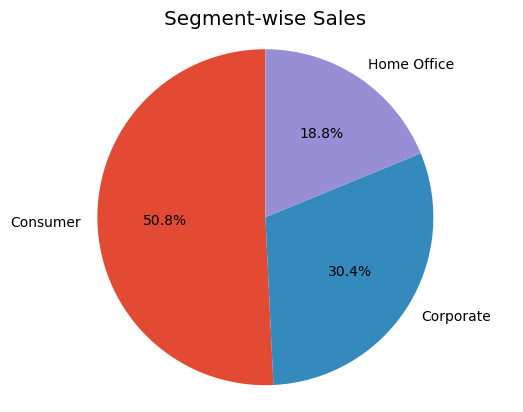

In [16]:
# Segment-wise Sales
segment = df.groupby('Segment')['Sales'].sum()

plt.pie(segment,labels=segment.index,startangle=90,autopct='%1.1f%%')

plt.title('Segment-wise Sales')
plt.axis('equal')# Makes the pie chart circular
plt.savefig('Chart5_Segment-wise_Sales',  dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


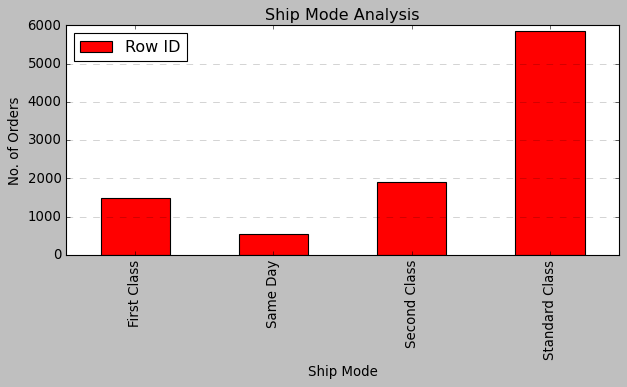

In [39]:
# Ship Mode Analysis
pivot=df.pivot_table(
    values='Row ID',
    index='Ship Mode',
    aggfunc='count'
)
plt.style.use('classic')
ax=pivot.plot(kind='bar',color='red',figsize=(8,5))
ax.set_title('Ship Mode Analysis')
ax.set_xlabel('Ship Mode')
ax.set_ylabel('No. of Orders')
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.savefig('chart6_Ship_Mode_Analysis',  dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


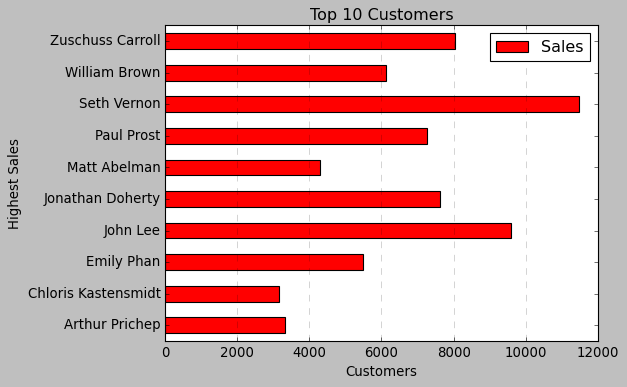

In [42]:
# Top 10 Customers

top10customers=df['Customer Name'].value_counts().head(10).index
topdf=df[df['Customer Name'].isin(top10customers)]
pivot=topdf.pivot_table(
    values='Sales',
    index='Customer Name',
    aggfunc='sum'
)

ax=pivot.plot(kind='barh',color=['red','blue','green'],figsize=(8,5))
ax.set_title('Top 10 Customers')
ax.set_xlabel('Customers')
ax.set_ylabel('Highest Sales')
ax.grid(axis='x',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.savefig('Chart7_Top_10_Customers',  dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

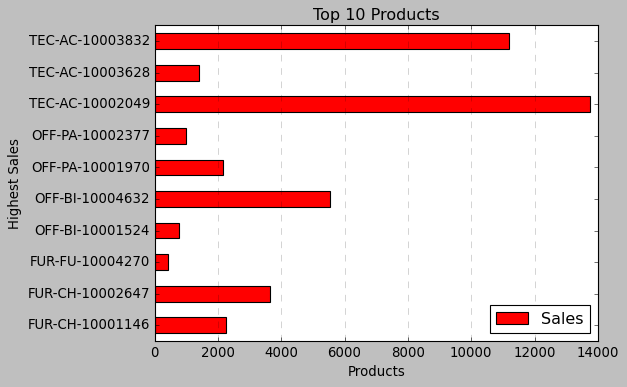

In [43]:
# Top 10 Products

top10products=df['Product ID'].value_counts().head(10).index
topdf=df[df['Product ID'].isin(top10products)]
pivot=topdf.pivot_table(
    values='Sales',
    index='Product ID',
    aggfunc='sum'
)

ax=pivot.plot(kind='barh',color=['red','blue','green'],figsize=(8,5))
ax.set_title('Top 10 Products')
ax.set_xlabel('Products')
ax.set_ylabel('Highest Sales')
ax.grid(axis='x',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.savefig('Chart8_Top_10_Products',  dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


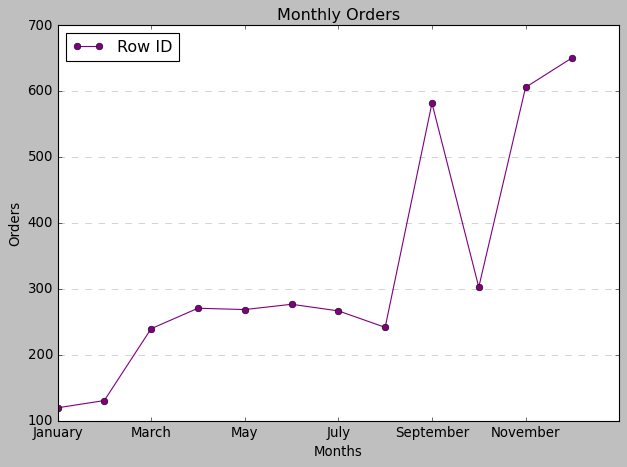

In [44]:
# Monthly Orders
pivot=df.pivot_table(
    values='Row ID',
    index=['Month_Number','Month'],
    aggfunc='count'
).sort_index()

##Display only month names remove Month_Number index
pivot.index=pivot.index.get_level_values('Month')

ax=pivot.plot(kind='line',color='purple',marker='o')
ax.set_title('Monthly Orders')
ax.set_xlabel('Months')
ax.set_ylabel('Orders')
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.savefig('Chart9_Monthly_Orders',  dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

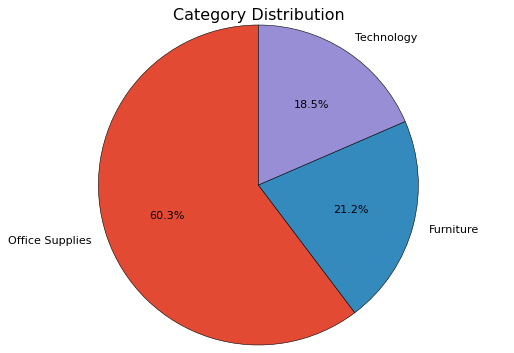

In [45]:
# Category Distribution

category=df['Category'].value_counts()
plt.style.use('ggplot')
plt.figure(figsize=(8,5))
plt.pie(category,labels=category.index,autopct='%1.1f%%',startangle=90, wedgeprops={'edgecolor':'black'})
plt.title('Category Distribution')
plt.axis('equal')
plt.savefig('Chart10_Category_Distribution',  dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()



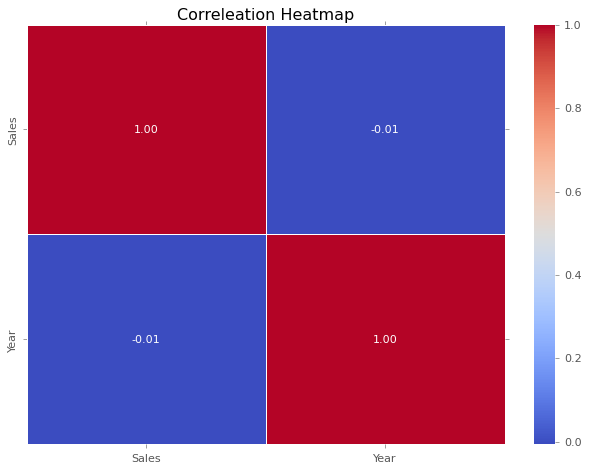

In [46]:

#Correleation Heatmap

corr=df[['Sales','Year']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',   fmt='.2f',
    linewidths=0.5)
plt.title('Correleation Heatmap')
plt.tight_layout()
plt.savefig('Chart11_Correleation_Heatmap',  dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()



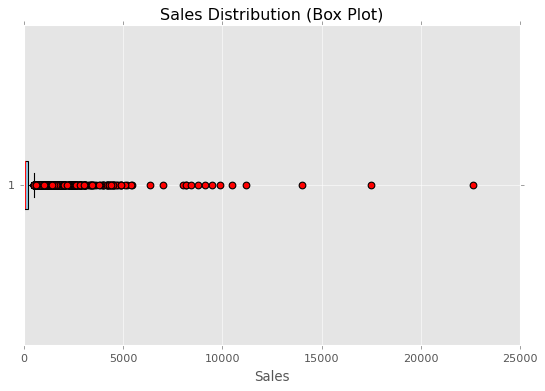

In [47]:
#Sales Distribution
plt.figure(figsize=(8,5))
plt.boxplot(df['Sales'], vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='black'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markersize=6,
        markeredgecolor='black'
    ))
plt.title('Sales Distribution (Box Plot)')
plt.xlabel('Sales')
plt.savefig('Chart12_Sales_Distribution',  dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


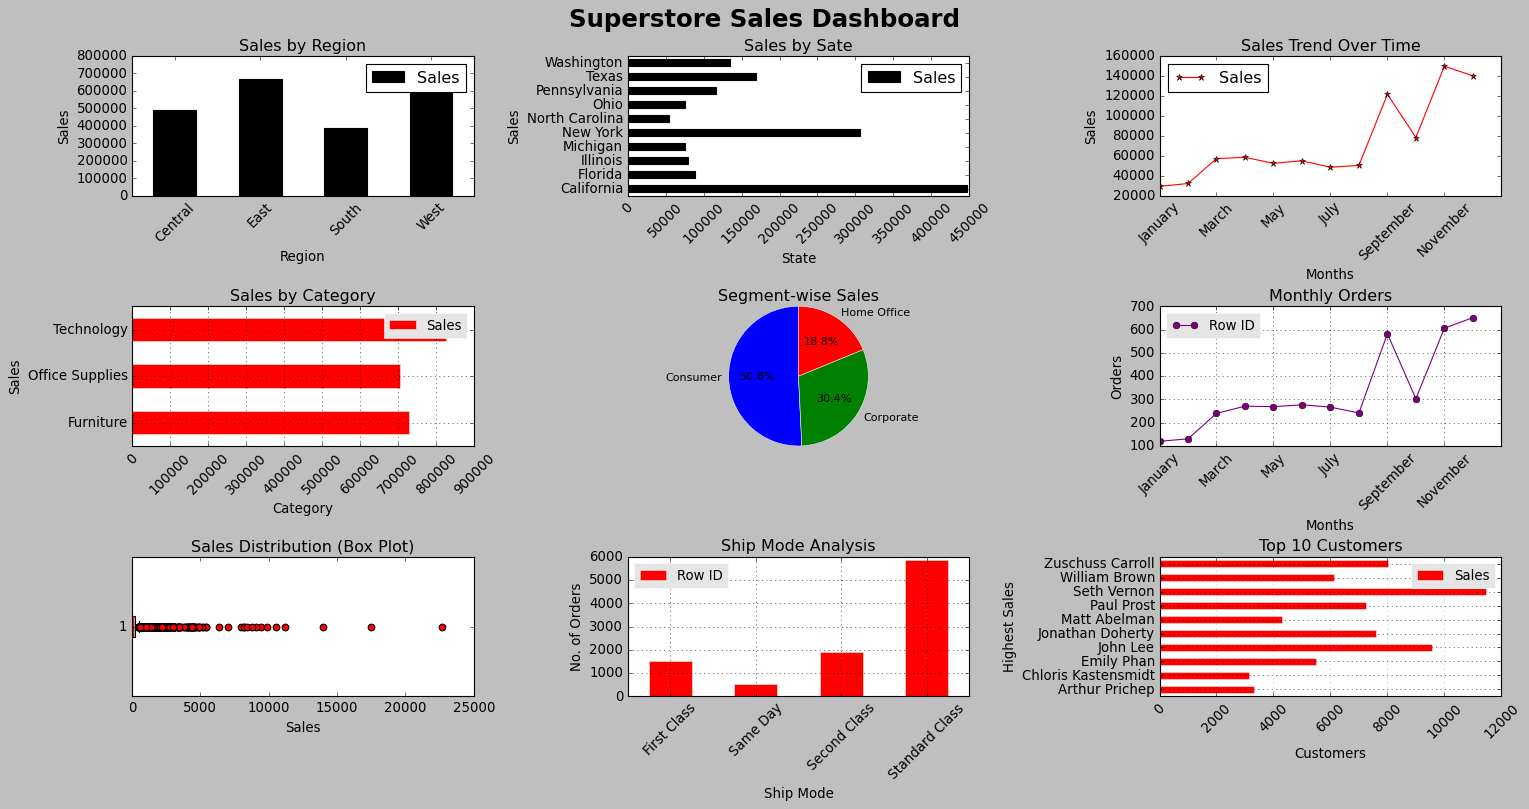

In [35]:
plt.style.use('classic')
fig,axes=plt.subplots(3,3,figsize=(19,10), constrained_layout=True)
fig.suptitle(
    "Superstore Sales Dashboard",
    fontsize=22,
    fontweight='bold'
)






pivot=df.pivot_table(
    values='Sales',
    index='Region',
    aggfunc='sum'
)

ax=pivot.plot(kind='bar',color='black',ax=axes[0,0])
ax.set_title('Sales by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Sales')
ax.tick_params(axis='x',labelrotation=45)
plt.grid(axis='x',alpha=0.3)








# Sales by State

topstates=df['State'].value_counts().head(10).index
topdf=df[df['State'].isin(topstates)]
pivot=topdf.pivot_table(
    values='Sales',
    index='State',
    aggfunc='sum'
)

ax=pivot.plot(kind='barh',color='black',ax=axes[0,1])
ax.set_title('Sales by Sate')
ax.set_xlabel('State')
ax.set_ylabel('Sales')
ax.tick_params(axis='x',labelrotation=45)
plt.grid(axis='x',alpha=0.3)




pivot=df.pivot_table(
    values='Sales',
    index=['Month_Number','Month'],
    aggfunc='sum'
).sort_index()

pivot.index=pivot.index.get_level_values('Month')

ax=pivot.plot(kind='line',color='red',marker='*',ax=axes[0,2])
ax.set_title('Sales Trend Over Time')
ax.set_xlabel('Months')
ax.set_ylabel('Sales')
ax.tick_params(axis='x',rotation=45)



#Sales by category
pivot=df.pivot_table(
    values='Sales',
    index='Category',
    aggfunc='sum'
)


plt.style.use('ggplot')
ax=pivot.plot(kind='barh',color='red',ax=axes[1,0])
ax.set_title('Sales by Category')
ax.set_xlabel('Category')
ax.set_ylabel('Sales')
ax.tick_params(axis='x',labelrotation=45)
plt.grid(axis='x',alpha=0.3)




# Segment-wise Sales
segment = df.groupby('Segment')['Sales'].sum()


axes[1,1].pie(segment,labels=segment.index,startangle=90,autopct='%1.1f%%')

axes[1,1].set_title('Segment-wise Sales')
axes[1,1].axis('equal')# Makes the pie chart circular



# Monthly Sales
pivot=df.pivot_table(
    values='Row ID',
    index=['Month_Number','Month'],
    aggfunc='count'
).sort_index()

pivot.index=pivot.index.get_level_values('Month')

ax=pivot.plot(kind='line',color='purple',marker='o',ax=axes[1,2])
ax.set_title('Monthly Orders')
ax.set_xlabel('Months')
ax.set_ylabel('Orders')
ax.tick_params(axis='x',labelrotation=45)
plt.grid(axis='x',alpha=0.3)






#Sales Distribution


axes[2,0].boxplot(df['Sales'], vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='black'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markersize=6,
        markeredgecolor='black'
    ))
axes[2,0].set_title('Sales Distribution (Box Plot)')
axes[2,0].set_xlabel('Sales')






# Ship Mode Analysis
pivot=df.pivot_table(
    values='Row ID',
    index='Ship Mode',
    aggfunc='count'
)



ax=pivot.plot(kind='bar',color='red',ax=axes[2,1])
ax.set_title('Ship Mode Analysis')
ax.set_xlabel('Ship Mode')
ax.set_ylabel('No. of Orders')
ax.tick_params(axis='x',labelrotation=45)
plt.grid(axis='x',alpha=0.3)





# Top 10 Customers

top10customers=df['Customer Name'].value_counts().head(10).index
topdf=df[df['Customer Name'].isin(top10customers)]
pivot=topdf.pivot_table(
    values='Sales',
    index='Customer Name',
    aggfunc='sum'
)

ax=pivot.plot(kind='barh',color=['red','blue','green'],ax=axes[2,2])
ax.set_title('Top 10 Customers')
ax.set_xlabel('Customers')
ax.set_ylabel('Highest Sales')
ax.tick_params(axis='x',labelrotation=45)
plt.grid(axis='x',alpha=0.3)
plt.savefig(
    "Superstore_Dashboard_HD.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)



plt.show()









